In [1]:
from torchmetrics.classification import MultilabelAveragePrecision
from torch.utils.data import DataLoader
from transformers import AutoImageProcessor
from datasets import load_dataset
import numpy as np
from transformers import AutoModel
from torch import nn, Tensor
import torch, dotenv, os

In [2]:
dotenv.load_dotenv()
token = os.getenv('HF_TOKEN')

device = 'cuda'

In [3]:
class Tagger(nn.Module):
    def __init__(self, cls_head: nn.Module):
        super().__init__()
        self.backbone_freeze = True

        self.backbone: nn.Module = AutoModel.from_pretrained('facebook/dinov2-base', token=token)
        self.backbone.requires_grad_(False)
        self.classifier = cls_head

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')

        last_layer = self.classifier[-1]
        nn.init.xavier_uniform_(last_layer.weight, gain=0.1)
        nn.init.zeros_(last_layer.bias)

    def forward(self, x):
        if (self.backbone_freeze):
            self.backbone.eval()

            with torch.no_grad():
                embeddings = self.backbone(x).last_hidden_state[:, 0]
        else:
            embeddings = self.backbone(x).last_hidden_state[:, 0]

        return self.classifier(embeddings)

    def freeze_backbone(self, mode=True):
        self.backbone_freeze = mode

        for layer in self.backbone.encoder.layer[-4:]:
            layer.requires_grad_(not mode)

head = nn.Sequential(
    nn.Linear(768, 256),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256, 30)
)

model = Tagger(head).to(device)

model.load_state_dict(torch.load('Best-E4.pt')['model_state_dict'])

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

<All keys matched successfully>

In [4]:
to_predict = (
    'female', 'male',
    'unicorn', 'pegasus', 'earth pony', 'alicorn',
    'simple background', 'monochrome',
    'clothes', 'wings', 'horn', 'chest fluff', 'ear fluff', 'hat', 'jewelry', 'food', 'foal',
    'looking at you', 'smiling', 'open mouth', 'blushing', 'sitting', 'raised hoof', 'eyes closed',
    'twilight sparkle', 'fluttershy', 'rainbow dash', 'pinkie pie', 'rarity', 'applejack'
)

In [5]:
ds = load_dataset('Brambles/Ponies', token=token)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/55 [00:00<?, ?it/s]

In [6]:
batch_size = 5

In [7]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base', token=token)

def transform(batch):
    images = [image.convert('RGB') for image in batch['image']]

    pixel_values = processor(
        images=images,
        return_tensors='pt',
    )["pixel_values"]

    return {
        "pixel_values": pixel_values,
        "tags": torch.tensor(batch['tags'], dtype=torch.float32),
    }

In [8]:
dl_test = DataLoader(
    ds['test'].with_transform(transform),
    batch_size=batch_size,
    pin_memory=True,
    num_workers=2,
    persistent_workers=True,
    shuffle=True
)

In [9]:
def test(model):
    model.eval()
    logits = torch.zeros((len(ds['test']), len(to_predict)))

    with torch.no_grad():
        for i, batch in enumerate(dl_test):
            X: Tensor = batch['pixel_values'].to(device)

            logits[i * batch_size : (i + 1) * batch_size] = model(X)
            print(f'\r{(i+1)*100/len(dl_test):.1f}%', end='')

        print()
        return logits.sigmoid()

In [10]:
# f = MultilabelAveragePrecision(len(to_predict), 'macro')

# preds = test(model)

# print(f'mAP: {f(preds, torch.as_tensor(ds['test']['tags'])):.4f}')

/tmp/ipykernel_11004/3256765261.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "tags": torch.tensor(batch['tags'], dtype=torch.float32),
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7556021..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].


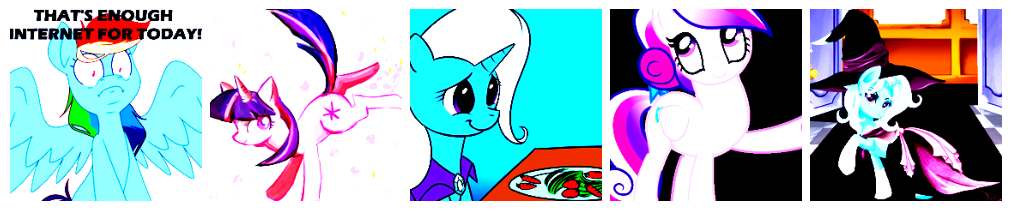

     rainbow dash:  1.00  1.0
          pegasus:  1.00  1.0
           female:  0.99  0.0
simple background:  0.98  1.0
            wings:  0.97  1.0
          smiling:  0.88  0.0
   looking at you:  0.65  0.0

 twilight sparkle:  1.00  1.0
             horn:  1.00  1.0
          unicorn:  1.00  1.0
           female:  0.99  1.0
simple background:  0.98  0.0
          smiling:  0.69  0.0
       open mouth:  0.58  0.0

             horn:  1.00  1.0
          unicorn:  1.00  1.0
             food:  0.98  1.0
           female:  0.98  1.0
          clothes:  0.87  0.0
          jewelry:  0.64  0.0
          smiling:  0.64  1.0

simple background:  1.00  1.0
      raised hoof:  0.99  0.0
           female:  0.98  1.0
          smiling:  0.92  0.0
          pegasus:  0.90  0.0
   looking at you:  0.74  0.0

          clothes:  1.00  1.0
             horn:  1.00  1.0
          unicorn:  1.00  1.0
              hat:  1.00  1.0
      raised hoof:  0.99  1.0
          smiling:  0.97  1.0
      

In [17]:
from utils import visualize
import numpy as np

#np.random.seed(0)
idx_obs = np.random.choice(len(ds['test']), 5, False)
X, y = zip(*[(ds['test'][i]['image'], ds['test'][i]['tags']) for i in idx_obs])

batch = transform({ 'image': X, 'tags': torch.tensor(y) })
X, y = batch['pixel_values'].to(device), batch['tags'].to(device)

with torch.no_grad():
    model.eval()

    logits = model(X).to(device)
    logits = logits.sigmoid()

    visualize(X.cpu(), y.cpu(), logits.cpu().numpy(), to_predict)